In [14]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

In [15]:
gas_plants = gpd.read_file("Manufactured_Gas_Plant_Sites.geojson")
counties = gpd.read_file("North_Carolina_State_and_County_Boundary_Polygons.geojson")
watersheds = gpd.read_file("dwq_wsws_20141126_-1629323221143849216.geojson")
benthos = gpd.read_file("NC_DWR_Benthos_Sample_Results.geojson")
water_report = pd.read_csv("Water System Summary_20261008.csv")

In [16]:
watersheds = watersheds.to_crs(epsg=2264)

In [17]:
watersheds.crs

<Projected CRS: EPSG:2264>
Name: NAD83 / North Carolina (ftUS)
Axis Info [cartesian]:
- X[east]: Easting (US survey foot)
- Y[north]: Northing (US survey foot)
Area of Use:
- name: United States (USA) - North Carolina - counties of Alamance; Alexander; Alleghany; Anson; Ashe; Avery; Beaufort; Bertie; Bladen; Brunswick; Buncombe; Burke; Cabarrus; Caldwell; Camden; Carteret; Caswell; Catawba; Chatham; Cherokee; Chowan; Clay; Cleveland; Columbus; Craven; Cumberland; Currituck; Dare; Davidson; Davie; Duplin; Durham; Edgecombe; Forsyth; Franklin; Gaston; Gates; Graham; Granville; Greene; Guilford; Halifax; Harnett; Haywood; Henderson; Hertford; Hoke; Hyde; Iredell; Jackson; Johnston; Jones; Lee; Lenoir; Lincoln; Macon; Madison; Martin; McDowell; Mecklenburg; Mitchell; Montgomery; Moore; Nash; New Hanover; Northampton; Onslow; Orange; Pamlico; Pasquotank; Pender; Perquimans; Person; Pitt; Polk; Randolph; Richmond; Robeson; Rockingham; Rowan; Rutherford; Sampson; Scotland; Stanly; Stokes; Sur

In [18]:
gas_plants = gas_plants.to_crs(epsg=2264)

In [19]:
counties = counties.to_crs(epsg=2264)

In [20]:
benthos = benthos.to_crs(epsg=2264)

In [23]:
plants_in_watersheds = gpd.sjoin(gas_plants, watersheds, predicate= "within")
len(plants_in_watersheds)
plants_in_watersheds

,objectid,epaid,sitename,cerclis_n,siteaddr,sitecity,sitecounty,yrs_op,lead_rp,status,...,index_right,OBJECTID,class,STREAM_NAM,CL_DATE,PCA_TYPE,WSWS_PCA,ClassURL,Area_acers,SecClass
15,16,NONCD0001085,Hickory MGP,Hickory Coal Gas Plant,625 12th Street Drive NW,Hickory,Catawba,1933-1948,PNG,I,...,316,317,WS-IV,Lake Hickory,8/3/92,P,WS-IVP,http://deq.nc.gov/about/divisions/water-resour...,15332.201671,None
16,17,NCD986188837,High Point MGP,High Point Coal Gas Plant,Centennial St and Kivett Drive,High Point,Guilford,1912-1948,Duke Power,I,...,281,282,WS-IV,Deep River (Randleman Lake),9/1/74,P,WS-IVP,http://deq.nc.gov/about/divisions/water-resour...,25022.565530,None


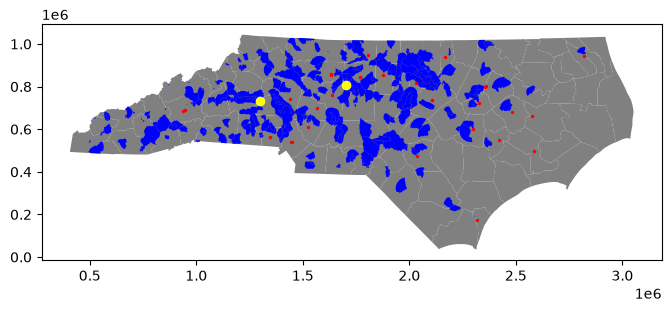

In [25]:
fig, ax = plt.subplots(figsize=(8,7))
counties.plot(ax=ax, color="grey")
watersheds.plot(ax=ax, color="blue")
gas_plants.plot(ax=ax, markersize=2, color="red")
plants_in_watersheds.plot(ax=ax, color="yellow")
plt.show()

It was at this point in the data analysis at which I decided to add the benthos data, originally